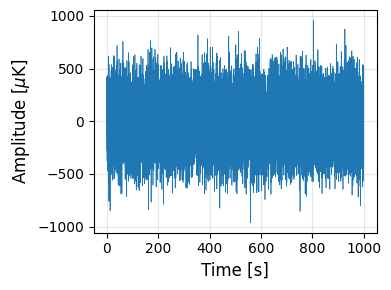

In [11]:
import litebird_sim as lbs
from astropy.time import Time
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import ducc0

start_time = 0
time_span_s = 1000.0

sim = lbs.Simulation(
    start_time=start_time,
    duration_s=time_span_s,
    random_seed=12345,
    imo=lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION) 
)

sim.set_scanning_strategy(
    lbs.SpinningScanningStrategy(
        spin_sun_angle_rad=np.deg2rad(0),
        precession_rate_hz=0,
        spin_rate_hz=1 / 60,
        start_time=start_time,
    ),
    delta_time_s=5.0,
)

sim.set_instrument(
    lbs.InstrumentInfo(
        boresight_rotangle_rad=0.0,
        spin_boresight_angle_rad=np.deg2rad(90),
        spin_rotangle_rad=np.deg2rad(75),
    )
)

det = lbs.DetectorInfo(
    name="Boresight_detector",
    sampling_rate_hz=20.,
    bandcenter_ghz=100.0,
    net_ukrts=50.0,
    fknee_mhz=2000.,
    fmin_hz=1e-5,
    alpha=1
)


obs = sim.create_observations(detectors=det)


# White Noise
lbs.noise.add_noise_to_observations(obs, 'white', dets_random=sim.dets_random)

tod = sim.observations[0].tod 


# PLOT: TOD
plt.figure(figsize=(4, 3))
time_axis = np.arange(tod.shape[1]) / det.sampling_rate_hz
plt.plot(time_axis, tod[0] * 1e6, linewidth=0.5)

plt.xlabel('Time [s]', fontsize=12)
plt.ylabel(r'Amplitude [$\mu$K]', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("white_noise.pdf") 
plt.show()

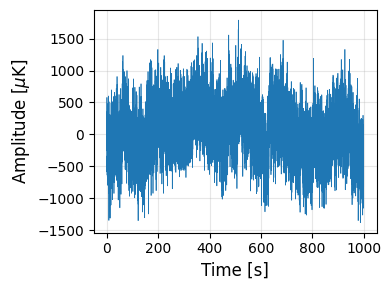

In [12]:
import litebird_sim as lbs
from astropy.time import Time
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import ducc0

start_time = 0
time_span_s = 1000.0

sim = lbs.Simulation(
    start_time=start_time,
    duration_s=time_span_s,
    random_seed=12345,
    imo=lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION) 
)

sim.set_scanning_strategy(
    lbs.SpinningScanningStrategy(
        spin_sun_angle_rad=np.deg2rad(0),
        precession_rate_hz=0,
        spin_rate_hz=1 / 60,
        start_time=start_time,
    ),
    delta_time_s=5.0,
)

sim.set_instrument(
    lbs.InstrumentInfo(
        boresight_rotangle_rad=0.0,
        spin_boresight_angle_rad=np.deg2rad(90),
        spin_rotangle_rad=np.deg2rad(75),
    )
)

det = lbs.DetectorInfo(
    name="Boresight_detector",
    sampling_rate_hz=20.,
    bandcenter_ghz=100.0,
    net_ukrts=50.0,
    fknee_mhz=2000.,
    fmin_hz=1e-5,
    alpha=1
)


obs = sim.create_observations(detectors=det)


# White Noise
lbs.noise.add_noise_to_observations(obs, 'one_over_f', dets_random=sim.dets_random)

tod = sim.observations[0].tod 


# PLOT: TOD
plt.figure(figsize=(4, 3))
time_axis = np.arange(tod.shape[1]) / det.sampling_rate_hz
plt.plot(time_axis, tod[0] * 1e6, linewidth=0.5)

plt.xlabel('Time [s]', fontsize=12)
plt.ylabel(r'Amplitude [$\mu$K]', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("1overf_noise.pdf") 
plt.show()